# Data Exploration
This notebook loads and performs a preliminary exploration of the CSV datasets located in the `../dataset` directory.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from IPython.display import display

# Configure plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Locate all CSV files in the dataset directory
dataset_dir = "../dataset"
csv_pattern = os.path.join(dataset_dir, "*.csv")
csv_files = glob.glob(csv_pattern)

print(f"Found {len(csv_files)} CSV files in '{dataset_dir}':")
for f in csv_files:
    print(f"- {os.path.basename(f)}")

Found 3 CSV files in '../dataset':
- airlines.csv
- flights_live.csv
- airports.csv


In [3]:
def explore_dataframe(df, name):
    """
    Performs basic exploration of a dataframe including:
    - Shape and data types
    - First few rows
    - Missing values
    - Descriptive statistics
    - Distribution plots for numeric columns
    """
    print(f"\n{'='*40}")
    print(f"Exploring: {name}")
    print(f"{'='*40}")
    
    # Basic Info
    print(f"\nShape: {df.shape}")
    print("\nData Types:")
    print(df.dtypes)
    
    # Preview
    print("\nFirst 5 rows:")
    display(df.head())
    
    # Missing Values
    print("\nMissing Values:")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print("No missing values found.")
        
    # Statistics
    print("\nDescriptive Statistics:")
    display(df.describe(include='all'))
    
    # Visualizations
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        print(f"\nPlotting distributions for {len(numeric_cols)} numeric columns...")
        df[numeric_cols].hist(bins=20, figsize=(15, 2 * ((len(numeric_cols) // 3) + 1)), layout=(-1, 3))
        plt.suptitle(f"Distributions - {name}", y=1.02)
        plt.tight_layout()
        plt.show()
        
        if len(numeric_cols) > 1:
            plt.figure(figsize=(10, 8))
            sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
            plt.title(f"Correlation Matrix - {name}")
            plt.show()


Exploring: airlines.csv

Shape: (14, 2)

Data Types:
IATA_CODE    str
AIRLINE      str
dtype: object

First 5 rows:


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways



Missing Values:
No missing values found.

Descriptive Statistics:


,IATA_CODE,AIRLINE
count,14,14
unique,14,14
top,UA,United Air Lines Inc.
freq,1,1



Exploring: flights_live.csv

Shape: (5771, 1)

Data Types:
fr24_id;flight;callsign;lat;lon;track;alt;gspeed;vspeed;squawk;timestamp;source;hex;type;reg;painted_as;operating_as;orig_iata;orig_icao;dest_iata;dest_icao;eta    str
dtype: object

First 5 rows:


...


Exploring: airports.csv

Shape: (322, 7)

Data Types:
IATA_CODE        str
AIRPORT          str
CITY             str
STATE            str
COUNTRY          str
LATITUDE     float64
LONGITUDE    float64
dtype: object

First 5 rows:


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447



Missing Values:
LATITUDE     3
LONGITUDE    3
dtype: int64

Descriptive Statistics:


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
count,322,322,322,322,322,319.000000,319.000000
unique,322,322,308,54,1,NaN,NaN
top,ABE,Lehigh Valley International Airport,Albany,TX,USA,NaN,NaN
freq,1,1,2,24,322,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,38.981244,-98.378964
std,NaN,NaN,NaN,NaN,NaN,8.616736,21.523492
min,NaN,NaN,NaN,NaN,NaN,13.483450,-176.646030
25%,NaN,NaN,NaN,NaN,NaN,33.652040,-110.839385
50%,NaN,NaN,NaN,NaN,NaN,39.297610,-93.403070
75%,NaN,NaN,NaN,NaN,NaN,43.154675,-82.722995



Plotting distributions for 2 numeric columns...


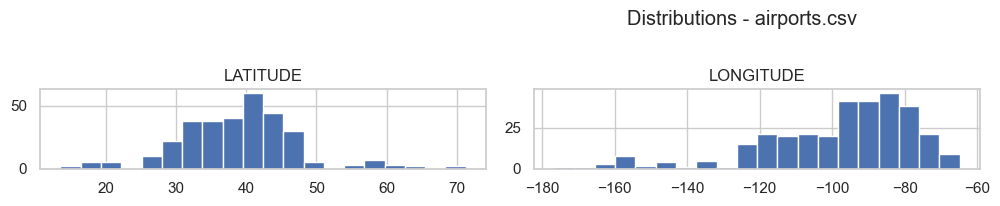

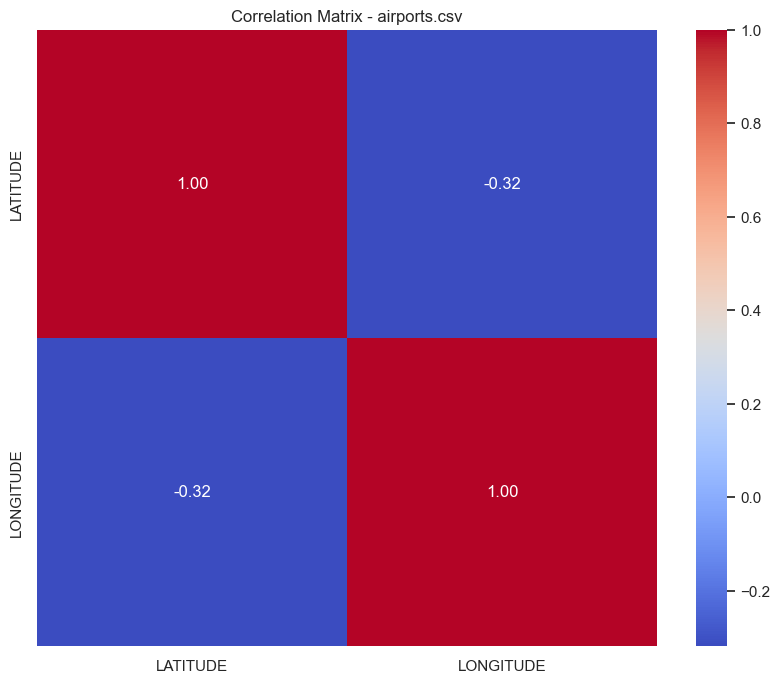

In [4]:
# Iterate through files and explore
for file_path in csv_files:
    try:
        filename = os.path.basename(file_path)
        # Read the CSV
        df = pd.read_csv(file_path)
        explore_dataframe(df, filename)
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")